In [0]:
dbutils.widgets.dropdown("shap_enabled", "true", ["true", "false"], "Compute shape feature importance")

# Use the best Auto-ML generated notebook to bootstrap our ML Project

<img src="https://raw.githubusercontent.com/QuentinAmbard/databricks-demo/main/retail/resources/images/lakehouse-retail/lakehouse-retail-churn-ml-experiment.png" style="float: right" width="600px">

Databricks Autt-ML tries many models and generate notebooks containing the code used to build the model.

Here, we selected the notebook from best run from the Auto ML experiment.

All the code below has been automatically generated. As Data Scientist, we can tune it based on our business knowledge, or use the model generated as it is.

This saves Datascientists hours of developement and allow team to quickly bootstrap and validate new project.


<!-- Collect usage data (view). Remove it to disable collection or disable tracker during installation. View README for more details.  -->
<img width="1px" src="https://ppxrzfxige.execute-api.us-west-2.amazonaws.com/v1/analytics?category=lakehouse&org_id=2162748966026566&notebook=%2F04-Data-Science-ML%2F04.2-automl-generated-notebook&demo_name=lakehouse-retail-c360&event=VIEW&path=%2F_dbdemos%2Flakehouse%2Flakehouse-retail-c360%2F04-Data-Science-ML%2F04.2-automl-generated-notebook&version=1">

In [0]:
%pip install databricks-sdk==0.36.0 mlflow==3.1.0
# Hardcode dbrml 16.4 version here to avoid version conflict
%pip install category-encoders==2.6.3 cffi==1.16.0 databricks-automl-runtime==0.2.21 defusedxml==0.7.1 holidays==0.54 lightgbm==4.5.0 lz4==4.3.2 matplotlib==3.8.4 numpy==1.26.4 pandas==2.2.3 psutil==5.9.0 pyarrow==15.0.2 scikit-learn==1.4.2 scipy==1.13.1 shap==0.46.0 https://github.com/databricks-demos/dbdemos-resources/raw/refs/heads/main/hyperopt-0.2.8-py3-none-any.whl
dbutils.library.restartPython()

  Using cached databricks_sdk-0.36.0-py3-none-any.whl.metadata (38 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached graphql_relay-3.2.0-py3-none-any.whl.metadata (12 kB)
Using cached databricks_sdk-0.36.0-py3-none-any.whl (569 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/24.7 MB ? eta -:--:--
   ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/24.7 MB 50.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━ 10.3/24.7 MB 161.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━ 19.2/24.7 MB 258.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 24.7/24.7 MB 261.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 24.7/24.7 MB 261.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.9 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.

In [0]:
%run ../_resources/00-setup $reset_all_data=false

USE CATALOG `main__build`
using catalog.database `main__build`.`dbdemos_retail_c360`


data already existing. Run with reset_all_data=true to force a data cleanup for your local demo.


# LightGBM training
This is an auto-generated notebook. To reproduce these results, attach this notebook to a DBRML cluster and rerun it.
- Compare trials in the MLflow experiment
- Navigate to the parent notebook
- Clone this notebook into your project folder by selecting **File > Clone** in the notebook toolbar.

Runtime Version: _8.4.x-cpu-ml-scala2.12_

In [0]:
import mlflow
#Added for the demo purpose
xp = DBDemos.get_last_experiment("lakehouse-retail-c360")
# Use MLflow to track experiments
mlflow.set_experiment(xp["path"])

#Run containing the data analysis notebook to get the data from artifact
data_run = mlflow.search_runs(experiment_ids=[xp['object_id']], filter_string="tags.mlflow.source.name='Notebook: DataExploration'").iloc[0].to_dict()

#get best run id (this notebook)
df = mlflow.search_runs(filter_string="metrics.val_f1_score < 1")
run = df.sort_values(by="metrics.val_f1_score", ascending=False).iloc[0].to_dict()

target_col = "churn"

## Load Data

In [0]:
# got an error running this cell? You probably need to re-run the previous notebook to get your experiment working.
import mlflow
import os
import uuid
import shutil
import pandas as pd

# Create temp directory to download input data from MLflow
input_temp_dir = os.path.join(os.environ["SPARK_LOCAL_DIRS"], "tmp", str(uuid.uuid4())[:8])
os.makedirs(input_temp_dir)


# Download the artifact and read it into a pandas DataFrame
input_data_path = mlflow.artifacts.download_artifacts(run_id=data_run['run_id'], artifact_path="data", dst_path=input_temp_dir)

df_loaded = pd.read_parquet(os.path.join(input_data_path, "training_data"))
# Delete the temp data
shutil.rmtree(input_temp_dir)

# Preview data
df_loaded.head(5)

,user_id,canal,country,gender,age_group,order_count,total_amount,total_item,last_transaction,platform,event_count,session_count,days_since_creation,days_since_last_activity,days_last_event,churn,_automl_split_col_0000
0,ccbd668a-50b1-485c-bb82-7b994fed0fd7,WEBAPP,FR,1,6,3,161,5,2023-06-07 20:26:46,ios,3,3,1521,915,920,0,train
1,9691861e-23fd-4ce4-b56a-e4ed0070c483,MOBILE,USA,1,6,4,146,7,2023-06-09 13:48:07,ios,4,4,1491,917,917,1,train
2,f3887f37-b523-400a-9bf7-584d39eee42a,WEBAPP,USA,1,6,2,87,5,2023-06-09 15:32:55,ios,2,2,1327,920,915,0,train
3,2f722ef9-a136-4300-9c53-5014897b93fb,MOBILE,SPAIN,1,1,1,56,2,2023-06-09 19:13:29,other,1,1,1356,915,915,1,train
4,2e6a4352-0191-4042-9398-a5166cca563a,WEBAPP,SPAIN,1,4,4,314,9,2023-06-08 04:23:26,other,4,4,1060,921,917,1,train


### Select supported columns
Select only the columns that are supported. This allows us to train a model that can predict on a dataset that has extra columns that are not used in training.
`["customer_id"]` are dropped in the pipelines. See the Alerts tab of the AutoML Experiment page for details on why these columns are dropped.

In [0]:
from databricks.automl_runtime.sklearn.column_selector import ColumnSelector
supported_cols = ["canal", "event_count", "days_since_creation", "country", "session_count", "order_count", "days_last_event", "last_transaction", "days_since_last_activity", "total_amount", "gender", "total_item", "age_group", "platform"]
col_selector = ColumnSelector(supported_cols)

## Preprocessors

### Datetime Preprocessor
For each datetime column, extract relevant information from the date:
- Unix timestamp
- whether the date is a weekend
- whether the date is a holiday

Additionally, extract extra information from columns with timestamps:
- hour of the day (one-hot encoded)

For cyclic features, plot the values along a unit circle to encode temporal proximity:
- hour of the day
- hours since the beginning of the week
- hours since the beginning of the month
- hours since the beginning of the year

In [0]:
from pandas import Timestamp
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from databricks.automl_runtime.sklearn import DatetimeImputer
from databricks.automl_runtime.sklearn import OneHotEncoder
from databricks.automl_runtime.sklearn import TimestampTransformer
from sklearn.preprocessing import StandardScaler

imputers = {
  "last_transaction": DatetimeImputer(),
}

datetime_transformers = []

for col in ["last_transaction"]:
    ohe_transformer = ColumnTransformer(
        [("ohe", OneHotEncoder(sparse=False, handle_unknown="indicator"), [TimestampTransformer.HOUR_COLUMN_INDEX])],
        remainder="passthrough")
    timestamp_preprocessor = Pipeline([
        (f"impute_{col}", imputers[col]),
        (f"transform_{col}", TimestampTransformer()),
        (f"onehot_encode_{col}", ohe_transformer),
        (f"standardize_{col}", StandardScaler()),
    ])
    datetime_transformers.append((f"timestamp_{col}", timestamp_preprocessor, [col]))

### Boolean columns
For each column, impute missing values and then convert into ones and zeros.

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import OneHotEncoder as SklearnOneHotEncoder


bool_imputers = []

bool_pipeline = Pipeline(steps=[
    ("cast_type", FunctionTransformer(lambda df: df.astype(object))),
    ("imputers", ColumnTransformer(bool_imputers, remainder="passthrough")),
    ("onehot", SklearnOneHotEncoder(handle_unknown="ignore", drop="first")),
])

bool_transformers = [("boolean", bool_pipeline, ["gender"])]

### Numerical columns

Missing values for numerical columns are imputed with mean by default.

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

num_imputers = []
num_imputers.append(("impute_mean", SimpleImputer(), ["age_group", "days_last_event", "days_since_creation", "days_since_last_activity", "event_count", "gender", "order_count", "session_count", "total_amount", "total_item"]))

numerical_pipeline = Pipeline(steps=[
    ("converter", FunctionTransformer(lambda df: df.apply(pd.to_numeric, errors='coerce'))),
    ("imputers", ColumnTransformer(num_imputers)),
    ("standardizer", StandardScaler()),
])

numerical_transformers = [("numerical", numerical_pipeline, ["event_count", "days_since_creation", "session_count", "order_count", "days_last_event", "total_amount", "days_since_last_activity", "gender", "total_item", "age_group"])]

### Categorical columns

#### Low-cardinality categoricals
Convert each low-cardinality categorical column into multiple binary columns through one-hot encoding.
For each input categorical column (string or numeric), the number of output columns is equal to the number of unique values in the input column.

In [0]:
from databricks.automl_runtime.sklearn import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

one_hot_imputers = []

one_hot_pipeline = Pipeline(steps=[
    ("imputers", ColumnTransformer(one_hot_imputers, remainder="passthrough")),
    ("one_hot_encoder", OneHotEncoder(handle_unknown="indicator")),
])

categorical_one_hot_transformers = [("onehot", one_hot_pipeline, ["age_group", "canal", "country", "days_last_event", "days_since_last_activity", "event_count", "order_count", "platform", "session_count"])]

In [0]:
from sklearn.compose import ColumnTransformer

transformers = datetime_transformers + bool_transformers + numerical_transformers + categorical_one_hot_transformers

preprocessor = ColumnTransformer(transformers, remainder="passthrough", sparse_threshold=0)

## Train - Validation - Test Split
The input data is split by AutoML into 3 sets:
- Train (60% of the dataset used to train the model)
- Validation (20% of the dataset used to tune the hyperparameters of the model)
- Test (20% of the dataset used to report the true performance of the model on an unseen dataset)

`_automl_split_col_8425` contains the information of which set a given row belongs to.
We use this column to split the dataset into the above 3 sets. 
The column should not be used for training so it is dropped after split is done.

In [0]:
# AutoML completed train - validation - test split internally and used _automl_split_col_xxxx to specify the set
split_col = [c for c in df_loaded.columns if c.startswith('_automl_split_col') or c == 'split'][0]

split_train_df = df_loaded.loc[df_loaded[split_col] == "train"]
split_val_df = df_loaded.loc[df_loaded[split_col].isin(["val", "validate"])]
split_test_df = df_loaded.loc[df_loaded[split_col] == "test"]

# Separate target column from features and drop _automl_split_col_xxx
X_train = split_train_df.drop([target_col, split_col], axis=1)
y_train = split_train_df[target_col]

X_val = split_val_df.drop([target_col, split_col], axis=1)
y_val = split_val_df[target_col]

X_test = split_test_df.drop([target_col, split_col], axis=1)
y_test = split_test_df[target_col]

if len(X_val) == 0: #hack for the demo to support all version - don't do that in production
    X_val = X_test
    y_val = y_test

## Train classification model
- Log relevant metrics to MLflow to track runs
- All the runs are logged under [this MLflow experiment](#mlflow/experiments/3087977229142441/s?orderByKey=metrics.%60val_f1_score%60&orderByAsc=false)
- Change the model parameters and re-run the training cell to log a different trial to the MLflow experiment
- To view the full list of tunable hyperparameters, check the output of the cell below

In [0]:
import lightgbm
from lightgbm import LGBMClassifier

help(LGBMClassifier)

Help on class LGBMClassifier in module lightgbm.sklearn:

class LGBMClassifier(sklearn.base.ClassifierMixin, LGBMModel)
 |  LGBMClassifier(boosting_type: str = 'gbdt', num_leaves: int = 31, max_depth: int = -1, learning_rate: float = 0.1, n_estimators: int = 100, subsample_for_bin: int = 200000, objective: Union[str, Callable[[Optional[numpy.ndarray], numpy.ndarray], Tuple[numpy.ndarray, numpy.ndarray]], Callable[[Optional[numpy.ndarray], numpy.ndarray, Optional[numpy.ndarray]], Tuple[numpy.ndarray, numpy.ndarray]], Callable[[Optional[numpy.ndarray], numpy.ndarray, Optional[numpy.ndarray], Optional[numpy.ndarray]], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = None, class_weight: Union[Dict, str, NoneType] = None, min_split_gain: float = 0.0, min_child_weight: float = 0.001, min_child_samples: int = 20, subsample: float = 1.0, subsample_freq: int = 0, colsample_bytree: float = 1.0, reg_alpha: float = 0.0, reg_lambda: float = 0.0, random_state: Union[int, numpy.random.mtrand.RandomS

In [0]:
import mlflow
from mlflow.models import Model, infer_signature, ModelSignature
from mlflow.pyfunc import PyFuncModel
from mlflow import pyfunc
import sklearn
from sklearn import set_config
from sklearn.pipeline import Pipeline
from unittest import mock

from hyperopt import hp, tpe, fmin, STATUS_OK, Trials

# Create a separate pipeline to transform the validation dataset. This is used for early stopping.
mlflow.sklearn.autolog(disable=True)
pipeline_val = Pipeline([
    ("column_selector", col_selector),
    ("preprocessor", preprocessor),
])
pipeline_val.fit(X_train, y_train)
X_val_processed = pipeline_val.transform(X_val)
dataset = mlflow.data.from_pandas(X_train)

def objective(params):
  with mlflow.start_run(experiment_id=run['experiment_id'], run_name="lightgbm") as mlflow_run, mock.patch("mlflow.utils.environment.PYTHON_VERSION", DBDemos.get_python_version_mlflow()):
    lgbmc_classifier = LGBMClassifier(**params)
    mlflow.log_input(dataset, "training")

    model = Pipeline([
        ("column_selector", col_selector),
        ("preprocessor", preprocessor),
        ("classifier", lgbmc_classifier),
    ])

    # Enable automatic logging of input samples, metrics, parameters, and models
    mlflow.sklearn.autolog(
        log_input_examples=True,
        silent=True)

    model.fit(X_train, y_train, classifier__callbacks=[lightgbm.early_stopping(5), lightgbm.log_evaluation(0)], classifier__eval_set=[(X_val_processed,y_val)])

    
    # Log metrics for the training set
    mlflow_model = Model()
    pyfunc.add_to_model(mlflow_model, loader_module="mlflow.sklearn")
    pyfunc_model = PyFuncModel(model_meta=mlflow_model, model_impl=model)
    training_eval_result = mlflow.evaluate(
        model=pyfunc_model,
        data=X_train.assign(**{str(target_col):y_train}),
        targets=target_col,
        model_type="classifier",
        evaluator_config = {"log_model_explainability": False,
                            "metric_prefix": "training_" , "pos_label": 1 }
    )
    lgbmc_training_metrics = training_eval_result.metrics
    # Log metrics for the validation set
    val_eval_result = mlflow.evaluate(
        model=pyfunc_model,
        data=X_val.assign(**{str(target_col):y_val}),
        targets=target_col,
        model_type="classifier",
        evaluator_config = {"log_model_explainability": False,
                            "metric_prefix": "val_" , "pos_label": 1 }
    )
    lgbmc_val_metrics = val_eval_result.metrics
    # Log metrics for the test set
    test_eval_result = mlflow.evaluate(
        model=pyfunc_model,
        data=X_test.assign(**{str(target_col):y_test}),
        targets=target_col,
        model_type="classifier",
        evaluator_config = {"log_model_explainability": False,
                            "metric_prefix": "test_" , "pos_label": 1 }
    )
    lgbmc_test_metrics = test_eval_result.metrics

    loss = -lgbmc_val_metrics["val_f1_score"]

    # Truncate metric key names so they can be displayed together
    lgbmc_val_metrics = {k.replace("val_", ""): v for k, v in lgbmc_val_metrics.items()}
    lgbmc_test_metrics = {k.replace("test_", ""): v for k, v in lgbmc_test_metrics.items()}

    return {
      "loss": loss,
      "status": STATUS_OK,
      "val_metrics": lgbmc_val_metrics,
      "test_metrics": lgbmc_test_metrics,
      "model": model,
      "run": mlflow_run,
    }

(2025-12-09 16:53:50) WARNING: Hyperopt is deprecated for Databricks runtime for machine learning and will not be pre-installed in the next major version.


### Configure the hyperparameter search space
Configure the search space of parameters. Parameters below are all constant expressions but can be
modified to widen the search space. For example, when training a decision tree classifier, to allow
the maximum tree depth to be either 2 or 3, set the key of 'max_depth' to
`hp.choice('max_depth', [2, 3])`. Be sure to also increase `max_evals` in the `fmin` call below.

See https://docs.databricks.com/applications/machine-learning/automl-hyperparam-tuning/index.html
for more information on hyperparameter tuning as well as
http://hyperopt.github.io/hyperopt/getting-started/search_spaces/ for documentation on supported
search expressions.

For documentation on parameters used by the model in use, please see:
https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMClassifier.html

NOTE: The above URL points to a stable version of the documentation corresponding to the last
released version of the package. The documentation may differ slightly for the package version
used by this notebook.

In [0]:
space = {
  "colsample_bytree": 0.6894665418662436,
  "lambda_l1": 0.24114681074974328,
  "lambda_l2": 117.97769127793491,
  "learning_rate": 0.41044009194210707,
  "max_bin": 36,
  "max_depth": 8,
  "min_child_samples": 247,
  "n_estimators": 282,
  "num_leaves": 16,
  "path_smooth": 57.07445771956602,
  "subsample": 0.7845389221041094,
  "random_state": 418579392,
}

### Run trials
When widening the search space and training multiple models, switch to `SparkTrials` to parallelize
training on Spark:
```
from hyperopt import SparkTrials
trials = SparkTrials()
```

NOTE: While `Trials` starts an MLFlow run for each set of hyperparameters, `SparkTrials` only starts
one top-level run; it will start a subrun for each set of hyperparameters.

See http://hyperopt.github.io/hyperopt/scaleout/spark/ for more info.

In [0]:
trials = Trials()
fmin(objective,
     space=space,
     algo=tpe.suggest,
     max_evals=1,  # Increase this when widening the hyperparameter search space.
     trials=trials)

best_result = trials.best_trial["result"]
model = best_result["model"]
mlflow_run = best_result["run"]

display(
  pd.DataFrame(
    [best_result["val_metrics"], best_result["test_metrics"]],
    index=pd.Index(["validation", "test"], name="split")).reset_index())

set_config(display="diagram")
model

[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24114681074974328
[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24114681074974328
[LightGBM] [Info] Number of positive: 26274, number of negative: 13774
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 601
[LightGBM] [Info] Number of data points in the train set: 40048, number of used features: 80
[LightGBM] [Warning] lambda_l2 is set=1

Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24114681074974328
  0%|          | 0/1 [00:13<?, ?trial/s, best loss=?]

2025/12/09 16:54:08 WARNING mlflow.models.evaluation.evaluators.classifier: According to the evaluation dataset label values, the model type looks like None, but you specified model type 'classifier'. Please verify that you set the `model_type` and `dataset` arguments correctly.



[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24114681074974328
[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24114681074974328
  0%|          | 0/1 [00:16<?, ?trial/s, best loss=?]

...

2025/12/09 16:54:16 INFO mlflow.models.evaluation.default_evaluator: Testing metrics on first row...



100%|██████████| 1/1 [00:26<00:00, 26.53s/trial, best loss: -0.8574138123396184]


split,score,true_negatives,false_positives,false_negatives,true_positives,example_count,accuracy_score,recall_score,precision_score,f1_score,log_loss,roc_auc,precision_recall_auc
validation,0.8106806903192356,3260,1380,1176,7685,13501,0.8106806903192356,0.8672836023022232,0.8477661334804192,0.8574138123396184,0.48191512054853114,0.7862076991777218,0.8322600085334301
test,0.8182021800806332,3282,1331,1104,7677,13394,0.8182021800806332,0.8742740006832935,0.8522424511545293,0.863117656979032,0.4733895247902615,0.7918566689361648,0.8335619623916172


Pipeline(steps=[('column_selector',
                 ColumnSelector(cols=['canal', 'event_count',
                                      'days_since_creation', 'country',
                                      'session_count', 'order_count',
                                      'days_last_event', 'last_transaction',
                                      'days_since_last_activity',
                                      'total_amount', 'gender', 'total_item',
                                      'age_group', 'platform'])),
                ('preprocessor',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transf...
                                                   'platform',
                                                   'session_count'])])),
                ('classifier',
                 LGBMClassifier(colsample_bytree=0.6894665418662436,
                                lambda_l1=0.24114681074974328,
                                lambda_l2=117.97769127793491,
                                learning_rate=0.41044009194210707, max_bin=36,
                                max_depth=8, min_child_samples=247,
                                n_estimators=282, num_leaves=16,
                                path_smooth=57.07445771956602,
                                random_state=418579392,
                                subsample=0.7845389221041094))])

<Figure size 1050x700 with 0 Axes>

### Patch pandas version in logged model

Ensures that model serving uses the same version of pandas that was used to train the model.

In [0]:
import mlflow
import os
import shutil
import tempfile
import yaml

run_id = mlflow_run.info.run_id

# Set up a local dir for downloading the artifacts.
tmp_dir = tempfile.mkdtemp()

client = mlflow.tracking.MlflowClient()

# Fix conda.yaml
conda_file_path = mlflow.artifacts.download_artifacts(artifact_uri=f"runs:/{run_id}/model/conda.yaml", dst_path=tmp_dir)
with open(conda_file_path) as f:
  conda_libs = yaml.load(f, Loader=yaml.FullLoader)
pandas_lib_exists = any([lib.startswith("pandas==") for lib in conda_libs["dependencies"][-1]["pip"]])
if not pandas_lib_exists:
  print("Adding pandas dependency to conda.yaml")
  conda_libs["dependencies"][-1]["pip"].append(f"pandas=={pd.__version__}")

  with open(f"{tmp_dir}/conda.yaml", "w") as f:
    f.write(yaml.dump(conda_libs))
  client.log_artifact(run_id=run_id, local_path=conda_file_path, artifact_path="model")

# Fix requirements.txt
venv_file_path = mlflow.artifacts.download_artifacts(artifact_uri=f"runs:/{run_id}/model/requirements.txt", dst_path=tmp_dir)
with open(venv_file_path) as f:
  venv_libs = f.readlines()
venv_libs = [lib.strip() for lib in venv_libs]
pandas_lib_exists = any([lib.startswith("pandas==") for lib in venv_libs])
if not pandas_lib_exists:
  print("Adding pandas dependency to requirements.txt")
  venv_libs.append(f"pandas=={pd.__version__}")

  with open(f"{tmp_dir}/requirements.txt", "w") as f:
    f.write("\n".join(venv_libs))
  client.log_artifact(run_id=run_id, local_path=venv_file_path, artifact_path="model")

shutil.rmtree(tmp_dir)

## Feature importance

SHAP is a game-theoretic approach to explain machine learning models, providing a summary plot
of the relationship between features and model output. Features are ranked in descending order of
importance, and impact/color describe the correlation between the feature and the target variable.
- Generating SHAP feature importance is a very memory intensive operation, so to ensure that AutoML can run trials without
  running out of memory, we disable SHAP by default.<br />
  You can set the flag defined below to `shap_enabled = True` and re-run this notebook to see the SHAP plots.
- To reduce the computational overhead of each trial, a single example is sampled from the validation set to explain.<br />
  For more thorough results, increase the sample size of explanations, or provide your own examples to explain.
- SHAP cannot explain models using data with nulls; if your dataset has any, both the background data and
  examples to explain will be imputed using the mode (most frequent values). This affects the computed
  SHAP values, as the imputed samples may not match the actual data distribution.

For more information on how to read Shapley values, see the [SHAP documentation](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html).

[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24114681074974328


  0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24114681074974328
[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24114681074974328
[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.24114681074974328
[LightGBM] [Warning] lambda_l2 is set=117.97769127793491, reg_lambda=0.0 will be ignored. Current value: lambda_l2=117.97769127793491
[LightGBM] [Warning] lambda_l1 is set=0.24114681074974328, 

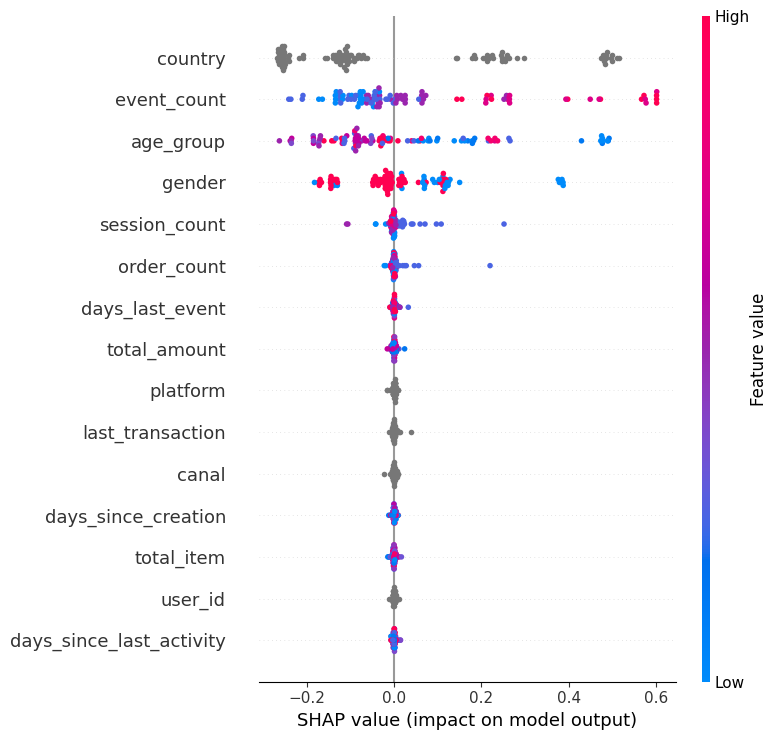

In [0]:
# Set this flag to True and re-run the notebook to see the SHAP plots
shap_enabled = dbutils.widgets.get("shap_enabled") == "true"
if shap_enabled:
    mlflow.autolog(disable=True)
    mlflow.sklearn.autolog(disable=True)
    from shap import KernelExplainer, summary_plot
    # Sample background data for SHAP Explainer. Increase the sample size to reduce variance.
    train_sample = X_train.sample(n=min(100, X_train.shape[0]), random_state=949709769)

    # Sample some rows from the validation set to explain. Increase the sample size for more thorough results.
    example = X_val.sample(n=min(100, X_val.shape[0]), random_state=949709769)

    # Use Kernel SHAP to explain feature importance on the sampled rows from the validation set.
    predict = lambda x: model.predict(pd.DataFrame(x, columns=X_train.columns))
    explainer = KernelExplainer(predict, train_sample, link="identity")
    shap_values = explainer.shap_values(example, l1_reg=False, nsamples=500)
    summary_plot(shap_values, example, class_names=model.classes_)

## Confusion matrix, ROC and Precision-Recall curves for validation data

We show the confusion matrix, ROC and Precision-Recall curves of the model on the validation data.

For the plots evaluated on the training and the test data, check the artifacts on the MLflow run page.

In [0]:
# Paste the entire output (%md ...) to an empty cell, and click the link to see the MLflow run page
displayHTML(f"""<a href="#mlflow/experiments/{ run['experiment_id'] }/runs/{ mlflow_run.info.run_id }/artifactPath/model">Link to model run page</a>""")

Link to model run page

In [0]:
import uuid
from IPython.display import Image

# Create temp directory to download MLflow model artifact
eval_temp_dir = os.path.join(os.environ["SPARK_LOCAL_DIRS"], "tmp", str(uuid.uuid4())[:8])
os.makedirs(eval_temp_dir, exist_ok=True)

# Download the artifact
eval_path = mlflow.artifacts.download_artifacts(run_id=mlflow_run.info.run_id, dst_path=eval_temp_dir)

(2025-12-09 16:55:58) WARNING: Connection pool is full, discarding connection: e2-demo-west-root.s3.us-west-2.amazonaws.com. Connection pool size: 10
(2025-12-09 16:55:58) WARNING: Connection pool is full, discarding connection: e2-demo-west-root.s3.us-west-2.amazonaws.com. Connection pool size: 10
(2025-12-09 16:55:58) WARNING: Connection pool is full, discarding connection: e2-demo-west-root.s3.us-west-2.amazonaws.com. Connection pool size: 10
(2025-12-09 16:55:58) WARNING: Connection pool is full, discarding connection: e2-demo-west-root.s3.us-west-2.amazonaws.com. Connection pool size: 10
(2025-12-09 16:55:58) WARNING: Connection pool is full, discarding connection: e2-demo-west-root.s3.us-west-2.amazonaws.com. Connection pool size: 10
(2025-12-09 16:55:58) WARNING: Connection pool is full, discarding connection: e2-demo-west-root.s3.us-west-2.amazonaws.com. Connection pool size: 10


### Confusion matrix for validation dataset

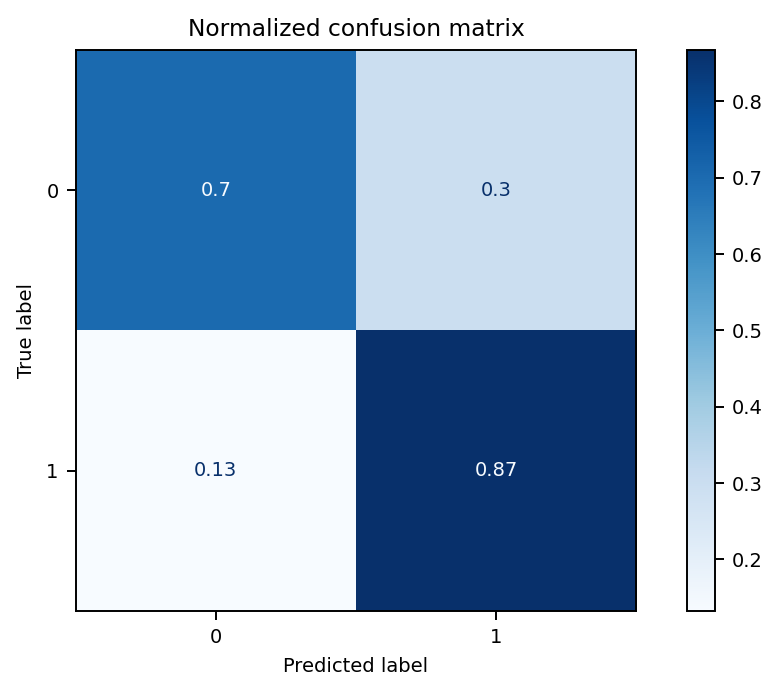

In [0]:
eval_confusion_matrix_path = os.path.join(eval_path, "val_confusion_matrix.png")
display(Image(filename=eval_confusion_matrix_path))

### ROC curve for validation dataset

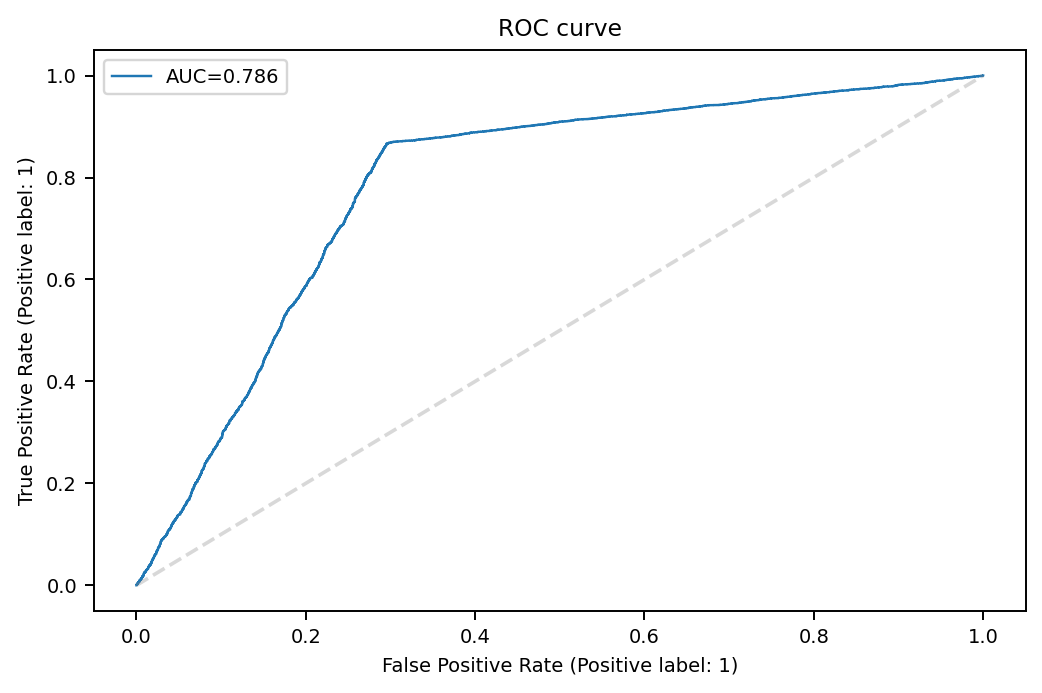

In [0]:
eval_roc_curve_path = os.path.join(eval_path, "val_roc_curve_plot.png")
display(Image(filename=eval_roc_curve_path))

### Precision-Recall curve for validation dataset

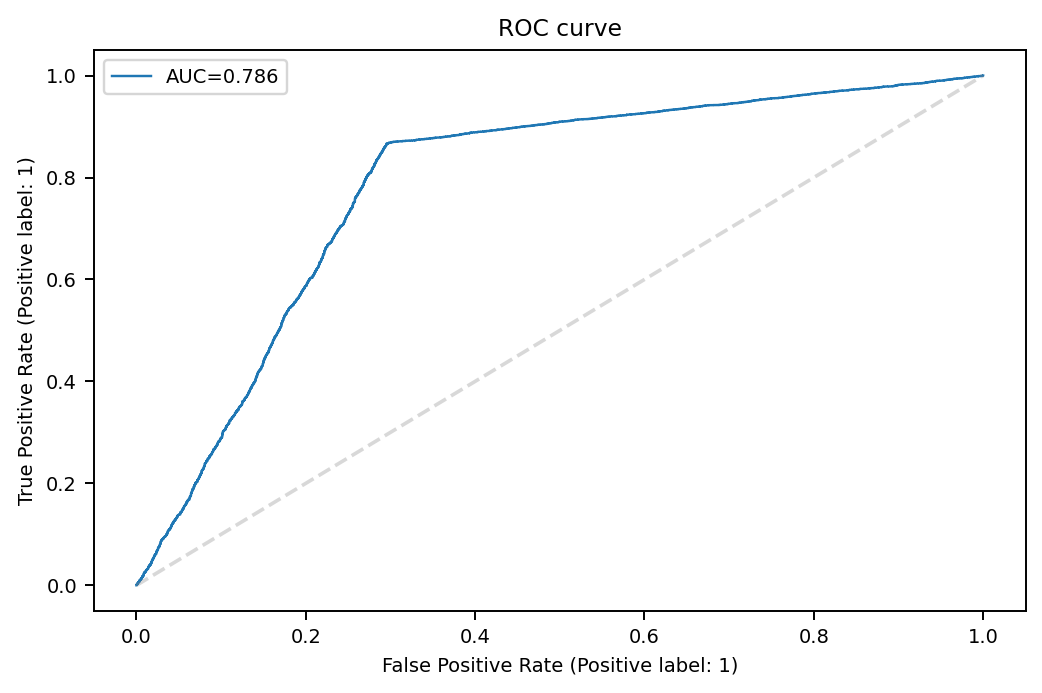

In [0]:
eval_roc_curve_path = os.path.join(eval_path, "val_roc_curve_plot.png")
display(Image(filename=eval_roc_curve_path))

### MLFlow tracked all our model information and the model is ready to be deployed in our registry!
We can do that manually:

<img src="https://github.com/QuentinAmbard/databricks-demo/raw/main/retail-cdc-forecast/resources/images/mlflow_artifact.gif" alt="MLFlow artifacts"/>

or using MLFlow APIs directly:

In [0]:
from mlflow import MlflowClient
model_name = "dbdemos_customer_churn"

#Set to true to redeploy your actual model (we skip it by default to make the demo faster)
force_redeploy = True

#Use Databricks Unity Catalog to save our model
mlflow.set_registry_uri('databricks-uc')
client = MlflowClient()
try:
  #Get the model if it is already registered to avoid re-deploying the endpoint
  latest_model = client.get_model_version_by_alias(f"{catalog}.{db}.{model_name}", "prod")
  print(f"Our model is already deployed on UC: {catalog}.{db}.{model_name}")
except:  
  #Enable Unity Catalog with mlflow registry
  #Add model within our catalog
  force_redeploy = True
  
if force_redeploy:
  latest_model = mlflow.register_model(f'runs:/{mlflow_run.info.run_id}/model', f"{catalog}.{db}.{model_name}")
  # Flag it as Production ready using UC Aliases
  client.set_registered_model_alias(name=f"{catalog}.{db}.{model_name}", alias="prod", version=latest_model.version)
  #set_model_permission(f"{catalog}.{db}.{model_name}", "ALL_PRIVILEGES", "account users")

Our model is already deployed on UC: main.dbdemos_retail_c360.dbdemos_customer_churn


Registered model 'main.dbdemos_retail_c360.dbdemos_customer_churn' already exists. Creating a new version of this model...
2025/12/09 16:56:00 WARNING mlflow.tracking._model_registry.fluent: Run with id 7b80099358924bd1b17158290fa1d600 has no artifacts at artifact path 'model', registering model based on models:/m-e6bb3f2b53664909a0699d5ef73a494b instead


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

(2025-12-09 16:56:03) WARNING: Connection pool is full, discarding connection: databricks-e2demofieldengwest.s3.us-west-2.amazonaws.com. Connection pool size: 10
(2025-12-09 16:56:03) WARNING: Connection pool is full, discarding connection: databricks-e2demofieldengwest.s3.us-west-2.amazonaws.com. Connection pool size: 10
🔗 Created version '47' of model 'main.dbdemos_retail_c360.dbdemos_customer_churn': https://xxxx.cloud.databricks.com/explore/data/models/main__build/dbdemos_retail_c360/dbdemos_customer_churn/version/47?o=1660015457675682


We just moved our model as production ready! [Open the dbdemos_customer_churn model](#mlflow/models/dbdemos_customer_churn) to explore its artifact and analyze the parameters used, including traceability to the notebook used for its creation.


### Next: Deploying our model in production: batch or serverless inference 

Let's now see how we can deploy this model and run inferences in production to provide Churn insight for our business

Next: [04.3-running-inference]($./04.3-running-inference)